In [33]:
!pip3 install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
processed_data_path = '../data/processed/cleaned_club_loan_two.csv'

# Fallback for different execution environments (root vs notebooks folder)
if not os.path.exists(processed_data_path):
    processed_data_path = '../data/processed/cleaned_club_loan_two.csv'
  

df = pd.read_csv(processed_data_path)
df_copy = df.copy()
print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (389412, 32)


# 1. Loan Burden Analysis

<Axes: xlabel='loan_repayment_status', ylabel='loan_income_ratio'>

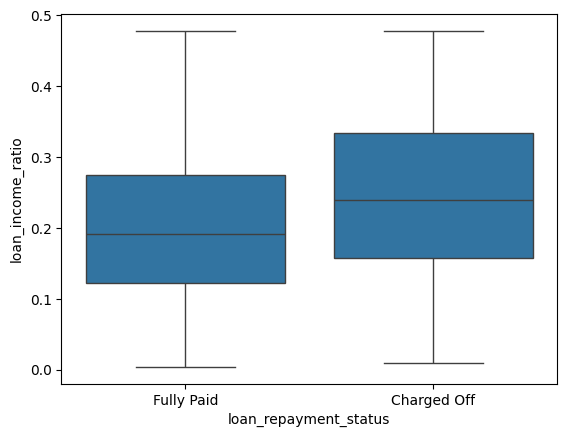

In [36]:
#Remove extreme values using percentile
df_filtered = df[df['loan_income_ratio'] < df['loan_income_ratio'].quantile(0.99)]

sns.boxplot(x='loan_repayment_status', y='loan_income_ratio', data=df_filtered)

## Insights

Loan-to-Income ratio measures how large a borrower’s loan is relative to their income, indicating repayment burden. A higher ratio means a larger portion of income is committed to the loan, increasing financial pressure.

**Higher Loan Burden, Higher Default Risk:** The boxplot shows that borrowers in the *Charged Off* category have a higher median loan-to-income ratio compared to *Fully Paid* borrowers. This indicates that individuals with heavier loan burdens are more likely to default.

**Lower Loan Burden, Safer Borrowers:** Borrowers who successfully repaid loans tend to have lower loan-to-income ratios, suggesting better affordability and financial stability.

**Shift in Distribution:** The entire distribution for defaulted borrowers is shifted upward, meaning not just a few outliers but a general trend of higher loan burden among defaulters.

**Consistent Risk Indicator:** Even after removing extreme values, the pattern remains strong, confirming that loan-to-income ratio is a reliable predictor of default risk.

---

## Business Strategy

**Loan Amount Optimization:** Lenders should limit loan amounts for borrowers with higher loan-to-income ratios to reduce repayment burden and minimize default risk.

**Affordability-Based Lending:** Incorporate strict loan-to-income thresholds in underwriting to ensure borrowers are not overburdened relative to their income.

**Risk-Based Pricing:** Charge higher interest rates for borrowers with higher loan burdens, while offering better rates to those with lower ratios.

**Pre-Approval Screening:** Use loan-to-income ratio as an early filter to identify high-risk applicants before deeper evaluation.

**Customized Repayment Plans:** Offer longer tenure or flexible EMI options to borrowers with moderately high ratios to ease repayment pressure.

**Portfolio Risk Management:** Monitor the distribution of loan-to-income ratios across the portfolio and avoid excessive exposure to high-burden borrowers.

---


Loan-to-income ratio is a strong indicator of repayment capacity, where higher borrower burden directly translates into increased default risk, making it a critical variable for responsible lending decisions.


# 2. Income Segmentation

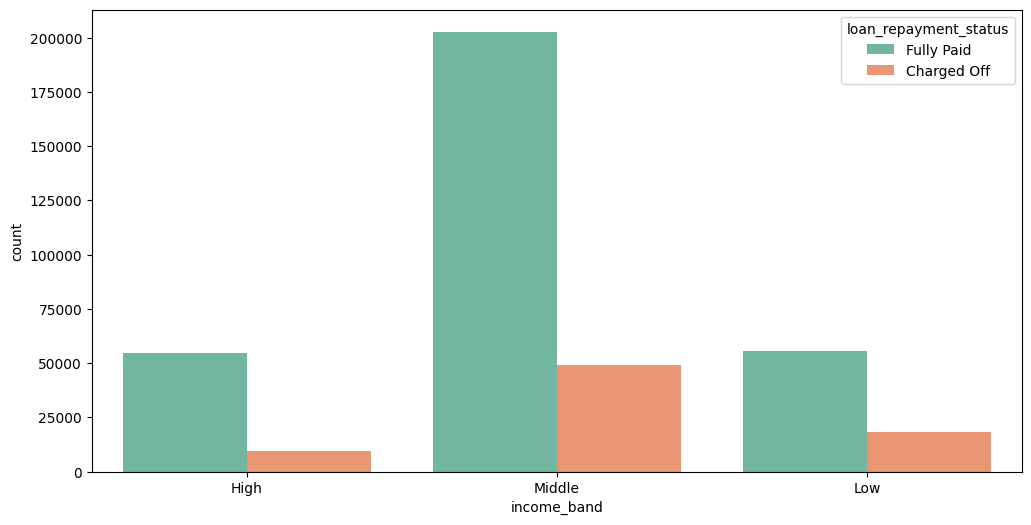

In [37]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='income_band',
    hue='loan_repayment_status',
    data=df,             
    palette='Set2'
)

plt.show()

## Insights 

### Proportional Default Rate:

  * The proportion of 'Charged Off' loans is generally highest in the 'Low' income band and progressively decreases as income moves to 'Middle' and 'High' bands. This indicates a clear trend: as income increases, the relative risk of default decreases.It should be a primary consideration in loan underwriting.

  * Lenders should implement differentiated risk assessment strategies across income bands, potentially with stricter criteria or higher interest rates for lower-income applicants to compensate for the elevated default risk


### Business Strategy:

  * Financial institutions could develop products tailored to different income segments. For instance, offering financial literacy programs or smaller, secured loans for lower-income individuals, and more flexible, larger loan options for higher-income individuals.

  * Marketing efforts can be segmented to highlight different benefits or risk mitigation strategies relevant to each income group.

  * Portfolio risk management can incorporate income band analysis to forecast potential defaults and allocate resources for collections or support programs more effectively.

# 3. DTI vs. Default Probability

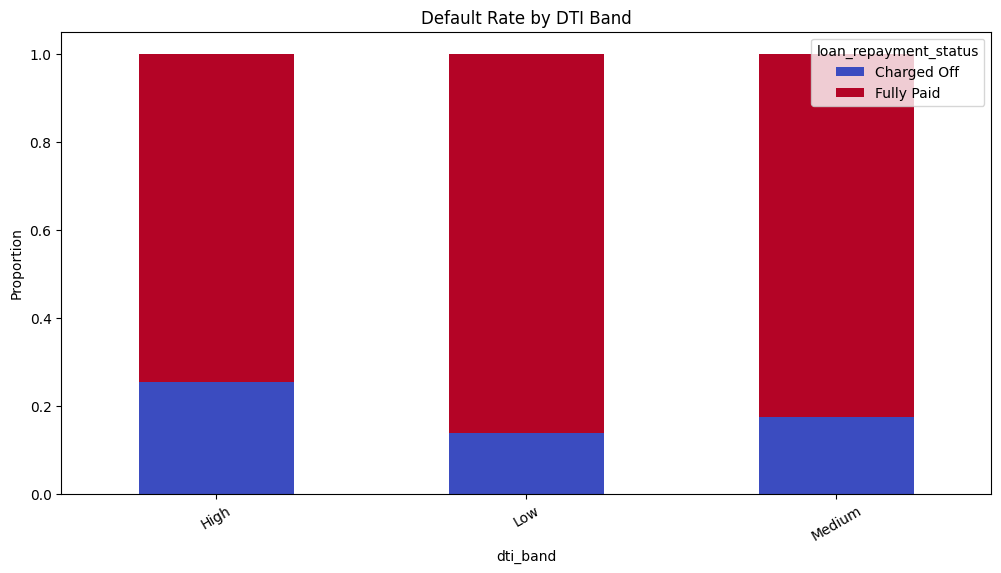

In [38]:
pd.crosstab(df['dti_band'], df['loan_repayment_status'], normalize='index') \
    .plot(kind='bar', stacked=True, figsize=(12,6), colormap='coolwarm')

plt.title('Default Rate by DTI Band')
plt.ylabel('Proportion')
plt.xticks(rotation=30)
plt.show()

## Insights

DTI stands for Debt-to-Income Ratio. It's a key financial metric used by lenders to assess a borrower's ability to manage monthly payments and repay debts.A lower DTI indicates that a borrower has more disposable income to cover their loan payments, generally suggesting a lower risk of default.

**Higher DTI, Higher Default Risk:** We observe that as the 'dti_band' moves from 'Low' to 'High', the proportion of 'Charged Off' (defaulted) loans generally increases. This means borrowers with a higher debt burden relative to their income are more likely to default on their loans.


**Lower DTI, Lower Default Risk:** Conversely, borrowers in the 'Low' DTI band are expected to have a larger proportion of 'Fully Paid' loans, indicating a lower risk of default.
 
**Differentiated Underwriting**:

Lenders should implement differentiated risk assessment strategies across DTI bands. Applicants in higher DTI bands may warrant stricter approval criteria, more conservative loan amounts, or higher interest rates to compensate for elevated default risk.

**Thresholds for Review**: 
Establish clear DTI thresholds that trigger more intensive review processes or even automatic decline for loans exceeding a certain DTI to mitigate high-risk exposures.

## Business Strategy:

  * Targeted Products: 
Financial institutions could develop specific loan products designed for borrowers in different DTI segments. For instance, offering debt consolidation loans with financial counseling for high-DTI individuals, or preferred rates for low-DTI borrowers.

  * Underwriting Policy Refinement: Incorporate DTI band analysis into underwriting policies to set explicit guidelines for loan approval, interest rate assignment, and collateral requirements based on a borrower's DTI.
   
  * Risk Mitigation Programs: For borrowers with higher DTI, consider proactive risk mitigation, such as offering smaller loan amounts, requiring co-signers, or providing financial education to help improve their debt management skills.

  * Portfolio Monitoring: Regularly monitor the DTI distribution within the existing loan portfolio to identify emerging risk trends and adjust lending strategies accordingly.



# 4. Credit Stress Analysis

In [9]:
# Create capped column
q99 = df['credit_stress_score'].quantile(0.99)

df['credit_stress_capped'] = df['credit_stress_score'].clip(upper=q99)

df.columns



Index(['loan_amount', 'loan_term', 'interest_rate', 'monthly_installment',
       'loan_grade', 'loan_sub_grade', 'home_ownership_status',
       'annual_income', 'income_verification_status', 'issue_date',
       'loan_repayment_status', 'loan_purpose', 'loan_title_description',
       'debt_to_income_ratio', 'earliest_credit_line_opened',
       'number_of_open_accounts', 'public_records_derogatory',
       'revolving_balance', 'revolving_line_utilization', 'total_credit_lines',
       'initial_listing_status', 'loan_application_type',
       'public_record_bankruptcies', 'borrower_full_address',
       'loan_income_ratio', 'installment_income_ratio', 'risk_score',
       'credit_stress_score', 'issue_year', 'income_band', 'dti_band',
       'utilization_band', 'credit_stress_capped'],
      dtype='str')

/var/folders/5w/q221yrhd6c99fl93ycz7_nk80000gn/T/ipykernel_67205/1982784273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


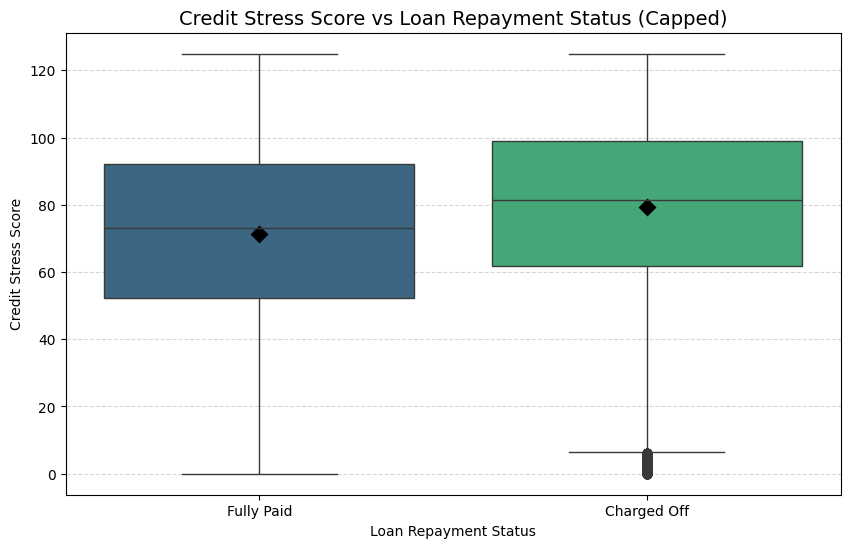

In [10]:
plt.figure(figsize=(10,6))

order = ['Fully Paid', 'Charged Off']

sns.boxplot(
    x='loan_repayment_status',
    y='credit_stress_capped',
    data=df,
    order=order,
    palette='viridis'
)

sns.pointplot(
    x='loan_repayment_status',
    y='credit_stress_capped',
    data=df,
    order=order,
    color='black',
    markers='D',
    linestyles=''
)

plt.title('Credit Stress Score vs Loan Repayment Status (Capped)', fontsize=14)
plt.xlabel('Loan Repayment Status')
plt.ylabel('Credit Stress Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Insights

* Borrowers in the *Charged Off* category have a **higher median and mean credit stress score** compared to *Fully Paid*, indicating stronger financial pressure among defaulters.

* The distribution is **shifted upward for defaulted borrowers**, showing that higher credit stress is directly associated with increased default risk.

* The spread of values is wider for *Charged Off*, suggesting **greater financial instability** among high-risk borrowers.

* After capping outliers, the pattern becomes clearer, confirming that **credit stress score is a reliable indicator of default risk**.

---

## Business Strategy

* **Stress-Based Lending:** Apply stricter approval criteria for borrowers with high credit stress scores.

* **Risk-Based Pricing:** Charge higher interest rates for high-stress borrowers and offer better rates to low-stress customers.

* **Early Warning System:** Monitor borrowers with rising credit stress scores to take proactive action before default.

* **Targeted Financial Support:** Offer restructuring or debt consolidation options to high-stress borrowers.

* **Portfolio Risk Control:** Limit exposure to high credit stress segments to maintain a stable loan portfolio.


# 5. Utilization Band Analysis

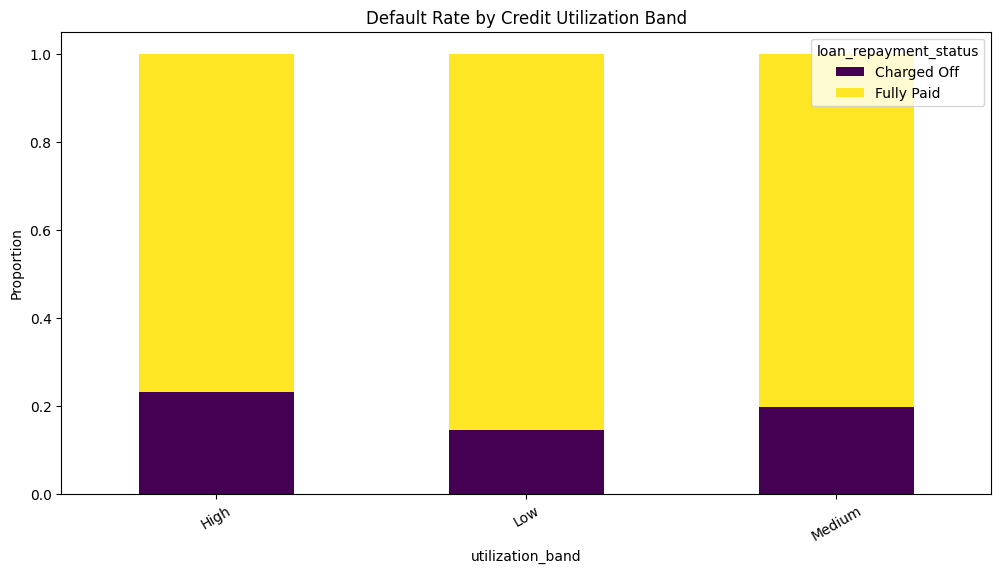

In [40]:
pd.crosstab(df['utilization_band'], df['loan_repayment_status'], normalize='index') \
    .plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')

plt.title('Default Rate by Credit Utilization Band')
plt.ylabel('Proportion')
plt.xticks(rotation=30)
plt.show()

## Insights

Credit utilization refers to how much of a borrower’s available credit they are using. It is a strong indicator of financial behavior and stress. Lower utilization suggests that a borrower is managing credit responsibly, while higher utilization indicates dependence on credit and possible financial pressure.

**Higher Utilization, Higher Default Risk:** The analysis shows that as the utilization band moves from low to high, the proportion of defaulted (charged off) loans increases. This indicates that borrowers who are using a large portion of their available credit are more likely to default, likely due to over-leverage and financial strain.

**Lower Utilization, Lower Default Risk:** Borrowers in the low utilization band have a higher proportion of fully paid loans, suggesting better financial discipline and repayment capacity. These customers are generally more stable and less risky.

**Clear Risk Gradient:** There is a consistent upward trend in default probability with increasing utilization, making credit utilization a reliable predictor of default risk.

---

## Business Strategy

**Risk-Based Lending:** Lenders should apply stricter approval criteria for high utilization borrowers, including reduced loan amounts or additional verification, while offering easier approvals for low utilization customers.

**Interest Rate Differentiation:** Interest rates should be adjusted based on utilization levels, with higher rates for high-risk (high utilization) borrowers and preferential rates for low-risk customers.

**Targeted Financial Products:** Financial institutions can design specific products such as debt consolidation loans for high utilization borrowers to reduce their financial burden, while offering premium products and credit line increases to low utilization customers.

**Early Risk Monitoring:** High utilization borrowers should be closely monitored as they act as early warning signals for potential defaults. Timely intervention can help reduce losses.

**Portfolio Risk Management:** Maintaining a balanced mix of borrowers across utilization bands is essential. Overexposure to high utilization customers should be avoided to ensure portfolio stability.

**Customer Education and Intervention:** Providing financial guidance and encouraging borrowers to maintain lower utilization levels can improve repayment behavior and reduce default rates over time.


# 6. Combined Financial Stress Analysis: DTI vs Credit Utilization

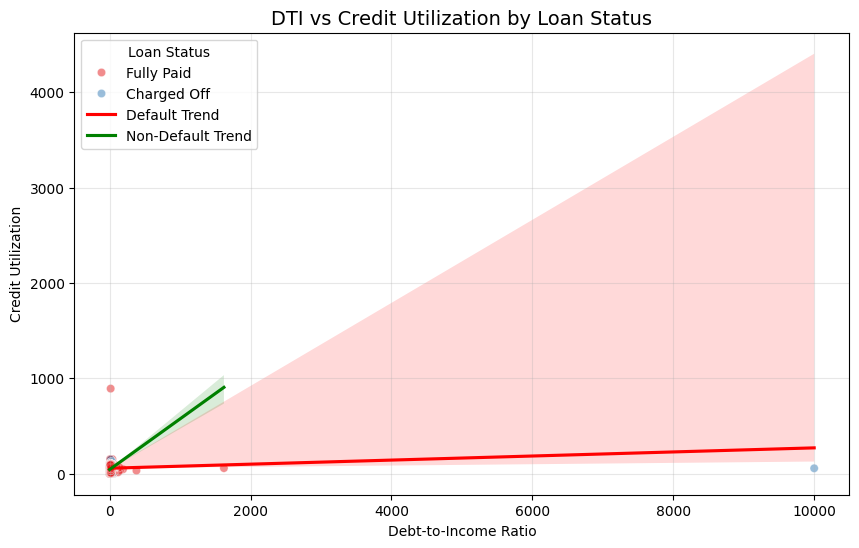

In [44]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='debt_to_income_ratio',
    y='revolving_line_utilization',
    hue='loan_repayment_status',
    data=df,
    alpha=0.5,
    palette='Set1'
)
sns.regplot(
    x='debt_to_income_ratio',
    y='revolving_line_utilization',
    data=df[df['loan_repayment_status']=='Charged Off'],
    scatter=False,
    color='red',
    label='Default Trend'
)

sns.regplot(
    x='debt_to_income_ratio',
    y='revolving_line_utilization',
    data=df[df['loan_repayment_status']=='Fully Paid'],
    scatter=False,
    color='green',
    label='Non-Default Trend'
)

plt.title('DTI vs Credit Utilization by Loan Status', fontsize=14)
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Credit Utilization')
plt.legend(title='Loan Status')
plt.grid(alpha=0.3)

plt.show()

## Insights

Debt-to-Income (DTI) ratio and credit utilization together provide a holistic view of a borrower’s financial health. DTI measures how much of a borrower’s income is already committed to debt payments, while credit utilization reflects how heavily they rely on available credit. When both metrics are high, it indicates significant financial pressure and reduced repayment capacity.

**High DTI + High Utilization, Higher Default Risk:** The analysis shows that borrowers who fall into regions with both high DTI and high credit utilization are more likely to default. This combination reflects over-leverage and dependency on credit, making it difficult for borrowers to manage additional loan obligations.

**Low DTI + Low Utilization, Lower Default Risk:** Borrowers with low DTI and low utilization are concentrated in the fully paid segment, indicating strong financial discipline and sufficient income to manage debts effectively. These borrowers represent the most stable and low-risk group.

**Compounded Financial Stress Effect:** The risk of default increases more sharply when both DTI and utilization rise together, rather than individually. This indicates that default risk is driven by the interaction of multiple financial stress factors rather than a single variable.

**Presence of High-Risk Clusters:** The visualization highlights clusters of defaulted borrowers in high-risk regions, reinforcing that these zones can be used to identify and segment risky customers effectively.

---

## Business Strategy

**Combined Risk-Based Lending:** Lenders should evaluate borrowers using a combination of DTI and credit utilization rather than relying on a single metric. Applicants with both high DTI and high utilization should undergo stricter approval processes or be denied credit.

**Risk-Based Pricing Strategy:** Borrowers in high-risk zones (high DTI + high utilization) should be charged higher interest rates to compensate for increased default risk, while low-risk borrowers should receive preferential pricing.

**Targeted Product Design:** Financial institutions can offer debt consolidation or restructuring products to high-risk borrowers to reduce their financial burden, while promoting premium credit products and higher limits to low-risk customers.

**Early Warning and Monitoring Systems:** Borrowers showing increasing trends in DTI and utilization should be flagged early. Proactive monitoring and intervention can help prevent defaults and reduce losses.

**Portfolio Risk Diversification:** Lenders should maintain a balanced distribution of borrowers across different risk segments and avoid excessive exposure to high-risk clusters identified in the analysis.

**Data-Driven Underwriting Policies:** Incorporate combined DTI and utilization thresholds into underwriting frameworks to define clear rules for loan approval, credit limits, and repayment terms based on borrower risk levels.


# 7. Risk Score Distribution

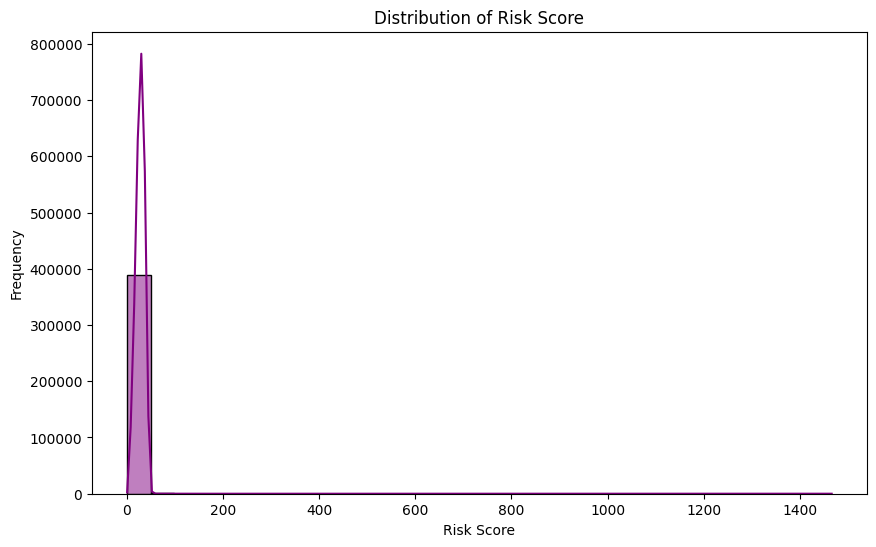

In [42]:
plt.figure(figsize=(10,6))
sns.histplot(df['risk_score'], kde=True, bins=30, color='purple')
plt.title('Distribution of Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.show()

## Insights

Risk score represents the overall risk level of a borrower by combining multiple financial indicators such as DTI, credit utilization, and income-related factors. It helps in summarizing borrower risk into a single measurable value for easier decision-making.

**Right-Skewed Distribution (Majority Low Risk):** The distribution is heavily skewed towards lower risk scores, indicating that most borrowers fall into the low to moderate risk category. This suggests that the majority of the portfolio consists of relatively safer borrowers.

**Presence of Extreme High-Risk Outliers:** A small number of borrowers have very high risk scores, creating a long tail on the right side of the distribution. These outliers represent highly risky customers who are significantly more likely to default.

**Risk Concentration in Lower Range:** Since most data points are concentrated in a narrow lower range, small differences in risk score within this region can still be meaningful for distinguishing between safe and moderately risky borrowers.

**Potential Scaling Issue:** The presence of extreme values stretching the distribution suggests that the risk score may need normalization or capping for better interpretability and modeling performance.

---

## Business Strategy

**Risk Segmentation:** Divide borrowers into categories such as low, medium, and high risk based on risk score thresholds. This enables more targeted and efficient decision-making in lending.

**Focused Risk Control on Outliers:** High-risk outliers should be carefully evaluated, with stricter approval criteria, reduced loan amounts, or possible rejection to avoid significant losses.

**Risk-Based Pricing:** Assign interest rates based on risk score levels. Higher scores should attract higher interest rates to compensate for increased default probability.

**Portfolio Optimization:** Since most borrowers are low risk, lenders can safely expand lending in this segment while limiting exposure to high-risk individuals to maintain portfolio stability.

**Score Normalization and Capping:** Apply transformations such as capping extreme values or scaling the risk score to improve model stability and make the score more interpretable.

**Monitoring and Early Intervention:** Continuously track borrowers with rising risk scores and intervene early through reminders, restructuring options, or financial guidance to prevent defaults.

---


The risk score effectively captures borrower risk distribution, where a majority of low-risk customers coexist with a small but critical segment of high-risk outliers that require focused risk management strategies.


# 8. Risk Score vs Loan Repayment Status

/var/folders/5w/q221yrhd6c99fl93ycz7_nk80000gn/T/ipykernel_15535/2582053391.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


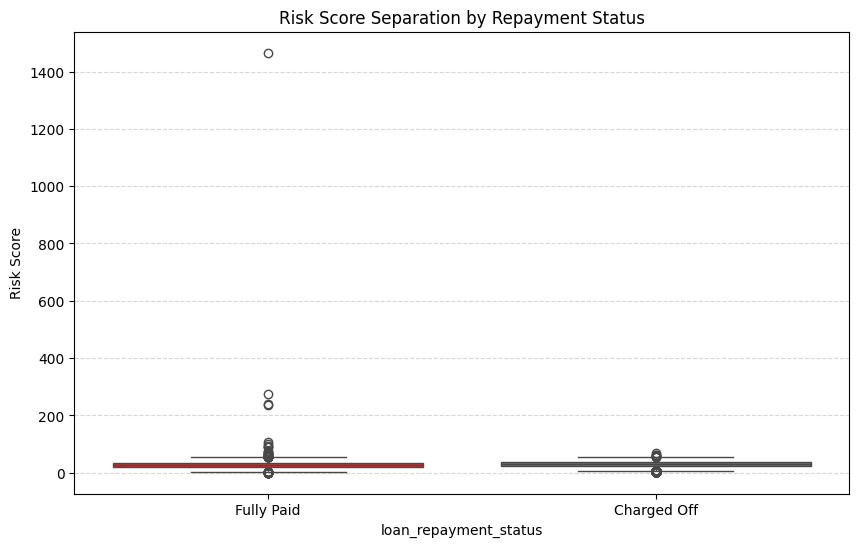

In [43]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='loan_repayment_status',
    y='risk_score',
    data=df,
    palette='Set1'
)
plt.title('Risk Score Separation by Repayment Status')
plt.ylabel('Risk Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Insights

* Borrowers in the *Charged Off* category have a **higher median risk score** than those who are *Fully Paid*, indicating that risk score is a strong indicator of default risk.

* The distribution is **shifted upward for defaulters**, showing that as risk score increases, the probability of default also increases.

* Despite slight overlap, the overall separation confirms that **risk score is an effective feature for distinguishing between low-risk and high-risk borrowers**.

---

## Business Strategy

* **Risk-Based Lending:** Implement stricter approval criteria and lower loan amounts for high-risk borrowers.

* **Risk-Based Pricing:** Assign higher interest rates to borrowers with higher risk scores and offer better rates to low-risk customers.

* **Customer Segmentation:** Classify borrowers into risk categories (low, medium, high) to tailor lending and marketing strategies.

* **Portfolio Risk Management:** Limit exposure to high-risk segments and maintain a balanced portfolio to reduce default risk.
